X: -3.1020097044041384
Y: 0.3262316635538121


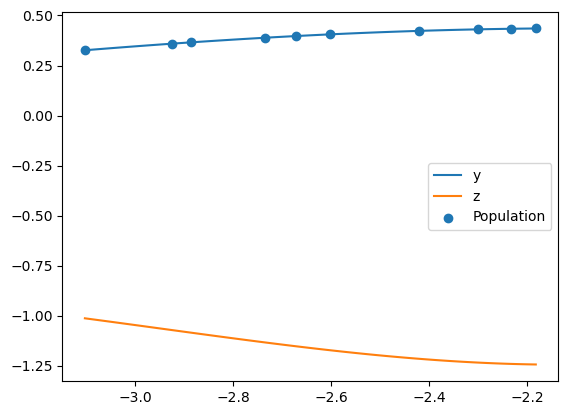

In [2]:
import numpy as np
from matplotlib import pyplot as plt

X_MIN, X_MAX = -5, -1
POPULATION = 10
GENERATIONS = 100

# Given mathematical functions
def y_function(x):
    return np.cos(x) / x - np.sin(x) / np.power(x, 2)

def z_function(x):
    return np.sin(x/2) + y_function(x) * np.sin(x)

# Population creation
def generate_population(x_min, x_max, size):
    return np.random.uniform(x_min, x_max, size)

# Sorting by score
def sort_population_by_fitness(population):
    return sorted(population, key=y_function)

def choice_from_population(population):
    sorted_pop = sort_population_by_fitness(population)
    pop_fitnesses = y_function(sorted_pop)
    fitnesses_sum = pop_fitnesses.sum()
    sum_probs = 0
    boundary = np.random.uniform(0, 1)
    for x, x_fitness in zip(sorted_pop, pop_fitnesses):
        sum_probs += x_fitness / fitnesses_sum
        if sum_probs >= boundary:
            return x

def crossover(xa, xb):
    return (xa + xb) / 2

# Mutation operator
def mutate(x):
    next_x = x + np.random.uniform(-0.5, 0.5)
    return np.clip(next_x, X_MIN, X_MAX)

# Creating the next generation
def make_next_generation(population):
    next_generation = []
    for _ in population:
        xa = choice_from_population(population)
        xb = choice_from_population(population)
        x = mutate(crossover(xa, xb))
        next_generation.append(x)
    return next_generation

def train(n_generations, n_pop):
    population = generate_population(x_min=X_MIN, x_max=X_MAX, size=n_pop)
    for _ in range(n_generations):
        population = make_next_generation(population)
        sorted_by_fitness = sort_population_by_fitness(population)
    return sorted_by_fitness

if __name__ == "__main__":
    population_sorted_by_fitness = train(GENERATIONS, POPULATION)
    print(f"X: {population_sorted_by_fitness[0]}")
    print(f"Y: {y_function(population_sorted_by_fitness[0])}")
    x = np.linspace(min(population_sorted_by_fitness),
                    max(population_sorted_by_fitness), 100)
    y = y_function(x)
    z = z_function(x)

    # Plot
    plt.plot(x, y, label='y')
    plt.plot(x, z, label='z')
    plt.scatter(population_sorted_by_fitness,
                y_function(population_sorted_by_fitness), label='Population')
    plt.legend()
    plt.show()


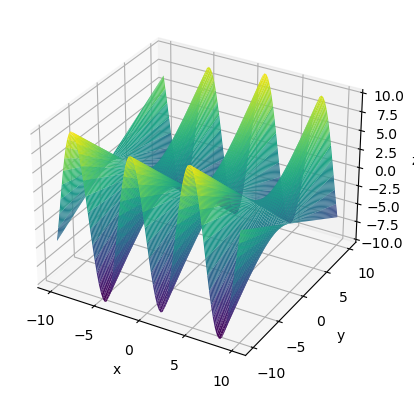

Generation 0
(x, y): (7.956989247311828, 8.817204301075268)
max: 7.999262817176695
Generation 10
(x, y): (7.878787878787879, 18.944281524926687)
max: 18.20337797157384
Generation 20
(x, y): (7.878787878787879, 18.944281524926687)
max: 18.20337797157384
Generation 30
(x, y): (7.878787878787879, 18.944281524926687)
max: 18.20337797157384
Generation 40
(x, y): (7.878787878787879, 18.944281524926687)
max: 18.20337797157384
Generation 50
(x, y): (7.878787878787879, 18.944281524926687)
max: 18.20337797157384
Generation 60
(x, y): (7.878787878787879, 18.944281524926687)
max: 18.20337797157384
Generation 70
(x, y): (7.878787878787879, 18.944281524926687)
max: 18.20337797157384
Generation 80
(x, y): (7.878787878787879, 18.944281524926687)
max: 18.20337797157384
Generation 90
(x, y): (7.878787878787879, 18.98338220918866)
max: 18.24246662615394

Final result:
(x, y): (7.878787878787879, 18.98338220918866)
max: 18.24246662615394


In [19]:
import numpy as np
from matplotlib import pyplot as plt

X_BOUND = [-10, 10]
Y_BOUND = [-10, 10]

def my_function(x, y):
    return (np.cos(x) / x - np.sin(x) / (x**2) + np.sin(x / 2) + y * np.sin(x))

POPULATION = 10
GENERATIONS = 100
DNA_SIZE = 10
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.05

def translateDNA(pop):
    x_pop = pop[:, 1::2]
    y_pop = pop[:, ::2]
    x = x_pop.dot(2 ** np.arange(DNA_SIZE)[::-1]) / float(2 ** DNA_SIZE - 1) * (X_BOUND[1] - X_BOUND[0])
    y = y_pop.dot(2 ** np.arange(DNA_SIZE)[::-1]) / float(2 ** DNA_SIZE - 1) * (Y_BOUND[1] - Y_BOUND[0])
    return x, y

def get_fitness(pop):
    x, y = translateDNA(np.array(pop))
    pred = my_function(x, y)
    return (pred - np.min(pred)) + 1e-3

def select(pop, fitness):
    idx = np.random.choice(np.arange(POPULATION), size=POPULATION, replace=True, p=(fitness) / (fitness.sum()))
    return [pop[i] for i in idx]

def crossover_and_mutation(pop, CROSSOVER_RATE=0.8):
    new_pop = []
    for father in pop:
        child = father.copy()
        if np.random.rand() < CROSSOVER_RATE:
            mother = pop[np.random.randint(POPULATION)].copy()
            cross_points = np.random.randint(low=0, high=DNA_SIZE * 2)
            child[cross_points:] = mother[cross_points:]
        mutation(child)
        new_pop.append(child)
    return new_pop

def mutation(child, MUTATION_RATE=0.003):
    if np.random.rand() < MUTATION_RATE:
        mutate_point = np.random.randint(0, DNA_SIZE * 2)
        child[mutate_point] = child[mutate_point] ^ 1

def plot_3d(ax):
    X = np.linspace(*X_BOUND, 100)
    Y = np.linspace(*Y_BOUND, 100)
    X, Y = np.meshgrid(X, Y)
    Z = my_function(X, Y)
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis')
    ax.set_zlim(-10, 10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    plt.show()

def print_info(pop):
    fitness = get_fitness(np.array(pop))
    max_fitness_index = np.argmax(fitness)
    x, y = translateDNA(np.array(pop))
    max_x, max_y = x[max_fitness_index], y[max_fitness_index]
    max_value = my_function(max_x, max_y)
    
    print(f"(x, y): ({max_x}, {max_y})")
    print(f"max: {max_value}")

if __name__ == "__main__":
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    plt.ion()
    plot_3d(ax)

    # Initialize population
    pop = np.random.randint(2, size=(POPULATION, DNA_SIZE * 2)).tolist()

    for generation in range(GENERATIONS):
        # Translate DNA and get fitness
        x, y = translateDNA(np.array(pop))
        fitness = get_fitness(np.array(pop))

        # Select and create the next generation
        pop = select(pop, fitness)
        pop = crossover_and_mutation(pop)

        # Display information about the current generation
        if generation % 10 == 0:
            print(f"Generation {generation}")
            print_info(pop)

    # Display final information
    print("\nFinal result:")
    print_info(pop)

    # Show the 3D plot
    plt.ioff()
    plt.show()
